In [1]:
"""
Bench2Drive Dataset Processor
A comprehensive pipeline for processing and analyzing the Bench2Drive dataset
"""

import os
import json
import gzip
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Any, Set
from multiprocessing import Pool, cpu_count
from functools import partial
import logging
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


class Bench2DriveProcessor:
    """Main processor for Bench2Drive dataset"""
    
    # Camera types and views
    CAMERA_VIEWS = ['front', 'front_left', 'front_right', 'back', 'back_left', 'back_right']
    CAMERA_TYPES = ['rgb', 'depth', 'instance', 'semantic']
    
    def __init__(self, root_dir: str, n_workers: int = None, val_scenarios: Set[str] = None, 
                 action_dict: Dict[int, Tuple] = None):
        """
        Initialize the processor
        
        Args:
            root_dir: Root directory of the Bench2Drive dataset
            n_workers: Number of parallel workers (default: cpu_count)
            val_scenarios: Set of validation scenario names
            action_dict: Dictionary mapping action indices to (throttle, steer, brake, reverse)
        """
        self.root_dir = Path(root_dir)
        self.n_workers = n_workers or cpu_count()
        self.val_scenarios = val_scenarios or []
        self.action_dict = action_dict or {}
        
        if not self.root_dir.exists():
            raise ValueError(f"Root directory does not exist: {root_dir}")
        
        logger.info(f"Initialized processor with root: {root_dir}")
        logger.info(f"Using {self.n_workers} workers")
    
    def get_scenarios(self) -> List[Path]:
        """Get all scenario directories"""
        scenarios = [d for d in self.root_dir.iterdir() if d.is_dir() and not d.name.startswith('.cache')]
        logger.info(f"Found {len(scenarios)} scenarios")
        return sorted(scenarios)
    
    def parse_scenario_name(self, scenario_path: Path) -> Dict[str, str]:
        """Parse scenario name into components"""
        name = scenario_path.name
        parts = name.split('_')
        
        # Initialize result
        result = {
            'full_scenario_name': name,
            'scenario_type': '',
            'town': '',
            'route': '',
            'weather_id': '',
            'route_number': None,
            'weather_number': None,
            'is_train': name not in self.val_scenarios
        }
        
        # Find indices of Town, Route, Weather
        town_idx = route_idx = weather_idx = -1
        for i, part in enumerate(parts):
            if part.startswith('Town'):
                town_idx = i
            elif part.startswith('Route'):
                route_idx = i
            elif part.startswith('Weather'):
                weather_idx = i
        
        # Extract components
        if town_idx > 0:
            result['scenario_type'] = '_'.join(parts[:town_idx])
        if town_idx >= 0:
            result['town'] = parts[town_idx]
        if route_idx >= 0:
            result['route'] = parts[route_idx]
            # Extract just the route number
            try:
                result['route_number'] = int(parts[route_idx].replace('Route', ''))
            except:
                result['route_number'] = None
        if weather_idx >= 0:
            result['weather_id'] = parts[weather_idx]
            # Extract just the weather number
            try:
                result['weather_number'] = int(parts[weather_idx].replace('Weather', ''))
            except:
                result['weather_number'] = None
        
        return result
    
    def load_can_data(self, json_gz_path: Path) -> Dict[str, Any]:
        """Load CAN bus data from compressed JSON file"""
        try:
            with gzip.open(json_gz_path, 'rt', encoding='utf-8') as gz_file:
                return json.load(gz_file)
        except Exception as e:
            logger.error(f"Error loading {json_gz_path}: {e}")
            return {}
    
    def get_expert_action(self, npz_path: Path) -> Tuple[Optional[float], ...]:
        """Load expert action from NPZ file"""
        try:
            data = np.load(npz_path)
            action_idx = int(data['arr_0'][-1])
            
            if self.action_dict and action_idx in self.action_dict:
                throttle, steer, brake, reverse = self.action_dict[action_idx]
                return throttle, steer, brake, action_idx
            else:
                return None, None, None, action_idx
        except Exception as e:
            logger.error(f"Error loading expert action from {npz_path}: {e}")
            return None, None, None, None
    
    def calculate_derivatives(self, current_acc: Dict[str, float], dt: float = 0.1) -> Dict[str, float]:
        """
        Calculate jerk and higher derivatives
        Note: This is a simplified calculation. For accurate derivatives,
        you'd need temporal data from consecutive frames.
        """
        derivatives = {}
        
        # Calculate acceleration magnitude
        acc_mag = np.sqrt(
            current_acc.get('x', 0)**2 + 
            current_acc.get('y', 0)**2 + 
            current_acc.get('z', 0)**2
        )
        
        # Simplified jerk estimation based on acceleration magnitude
        # In practice, you'd calculate this from consecutive frames
        derivatives['jerk_magnitude'] = acc_mag / dt if acc_mag > 0 else 0
        
        # Initialize other derivatives
        derivatives['snap_magnitude'] = 0.0
        derivatives['crackle_magnitude'] = 0.0
        derivatives['pop_magnitude'] = 0.0
        
        return derivatives
    
    def process_single_frame(self, scenario_path: Path, frame_num: str) -> Dict[str, Any]:
        """Process a single frame of data"""
        frame_data = {
            'frame': frame_num,
            'frame_int': int(frame_num),
            'scenario_path': str(scenario_path),
            # Initialize common fields with None
            'x': None, 'y': None, 'throttle': None, 'steer': None, 'brake': None,
            'speed': None, 'acc_x': 0, 'acc_y': 0, 'acc_z': 0,
            'acc_magnitude': 0, 'jerk_magnitude': 0,
            'ang_vel_x': 0, 'ang_vel_y': 0, 'ang_vel_z': 0,
            'ang_vel_magnitude': 0
        }
        
        # Parse scenario info
        scenario_info = self.parse_scenario_name(scenario_path)
        frame_data.update(scenario_info)
        
        # Load CAN bus data
        anno_path = scenario_path / 'anno' / f'{frame_num}.json.gz'
        if anno_path.exists():
            can_data = self.load_can_data(anno_path)
            
            # Extract basic CAN bus values
            basic_keys = ['x', 'y', 'throttle', 'steer', 'brake', 'reverse', 'theta', 
                         'speed', 'x_command_far', 'y_command_far', 'command_far',
                         'x_command_near', 'y_command_near', 'command_near',
                         'should_brake', 'x_target', 'y_target', 'next_command', 
                         'only_ap_brake']
            
            for key in basic_keys:
                frame_data[key] = can_data.get(key, None)
            
            # Extract weather data (it's a dictionary)
            if 'weather' in can_data and isinstance(can_data['weather'], dict):
                weather = can_data['weather']
                frame_data['cloudiness'] = weather.get('cloudiness', None)
                frame_data['precipitation'] = weather.get('precipitation', None)
                frame_data['precipitation_deposits'] = weather.get('precipitation_deposits', None)
                frame_data['wind_intensity'] = weather.get('wind_intensity', None)
                frame_data['sun_azimuth_angle'] = weather.get('sun_azimuth_angle', None)
                frame_data['sun_altitude_angle'] = weather.get('sun_altitude_angle', None)
                frame_data['fog_density'] = weather.get('fog_density', None)
                frame_data['fog_distance'] = weather.get('fog_distance', None)
                frame_data['wetness'] = weather.get('wetness', None)
                frame_data['fog_falloff'] = weather.get('fog_falloff', None)
            
            # Extract acceleration
            if 'acceleration' in can_data:
                acc = can_data['acceleration']
                if isinstance(acc, dict):
                    frame_data['acc_x'] = acc.get('x', 0)
                    frame_data['acc_y'] = acc.get('y', 0)
                    frame_data['acc_z'] = acc.get('z', 0)
                elif isinstance(acc, (list, tuple)) and len(acc) >= 3:
                    frame_data['acc_x'] = acc[0]
                    frame_data['acc_y'] = acc[1]
                    frame_data['acc_z'] = acc[2]
                
                # Calculate acceleration magnitude
                frame_data['acc_magnitude'] = np.sqrt(
                    frame_data.get('acc_x', 0)**2 + 
                    frame_data.get('acc_y', 0)**2 + 
                    frame_data.get('acc_z', 0)**2
                )
                
                # Calculate derivatives
                derivatives = self.calculate_derivatives(
                    {'x': frame_data.get('acc_x', 0),
                     'y': frame_data.get('acc_y', 0),
                     'z': frame_data.get('acc_z', 0)}
                )
                frame_data.update(derivatives)
            
            # Extract angular velocity
            if 'angular_velocity' in can_data:
                ang_vel = can_data['angular_velocity']
                if isinstance(ang_vel, dict):
                    frame_data['ang_vel_x'] = ang_vel.get('x', 0)
                    frame_data['ang_vel_y'] = ang_vel.get('y', 0)
                    frame_data['ang_vel_z'] = ang_vel.get('z', 0)
                elif isinstance(ang_vel, (list, tuple)) and len(ang_vel) >= 3:
                    frame_data['ang_vel_x'] = ang_vel[0]
                    frame_data['ang_vel_y'] = ang_vel[1]
                    frame_data['ang_vel_z'] = ang_vel[2]
                
                # Calculate angular velocity magnitude
                frame_data['ang_vel_magnitude'] = np.sqrt(
                    frame_data.get('ang_vel_x', 0)**2 + 
                    frame_data.get('ang_vel_y', 0)**2 + 
                    frame_data.get('ang_vel_z', 0)**2
                )
        
        # Add camera paths
        for cam_type in self.CAMERA_TYPES:
            for view in self.CAMERA_VIEWS:
                ext = 'jpg' if cam_type == 'rgb' else 'png'
                cam_path = scenario_path / 'camera' / f'{cam_type}_{view}' / f'{frame_num}.{ext}'
                frame_data[f'{cam_type}_{view}_path'] = str(cam_path) if cam_path.exists() else None
        
        # Add special RGB top-down view
        rgb_topdown_path = scenario_path / 'camera' / 'rgb_top_down' / f'{frame_num}.jpg'
        frame_data['rgb_top_down_path'] = str(rgb_topdown_path) if rgb_topdown_path.exists() else None
        
        # Add lidar and radar paths
        lidar_path = scenario_path / 'lidar' / f'{frame_num}.laz'
        frame_data['lidar_path'] = str(lidar_path) if lidar_path.exists() else None
        
        radar_path = scenario_path / 'radar' / f'{frame_num}.h5'
        frame_data['radar_path'] = str(radar_path) if radar_path.exists() else None
        
        # Get expert action - handle both -1 offset and normal numbering
        try:
            # First try the normal frame number
            expert_path = scenario_path / 'expert_assessment' / f'{frame_num}.npz'
            
            # If it doesn't exist, try with -1 offset
            if not expert_path.exists():
                expert_frame_num = int(frame_num) - 1
                expert_frame_str = f'{expert_frame_num:05d}'
                expert_path = scenario_path / 'expert_assessment' / f'{expert_frame_str}.npz'
            
            if expert_path.exists():
                throttle, steer, brake, action_idx = self.get_expert_action(expert_path)
                frame_data['expert_throttle'] = throttle
                frame_data['expert_steer'] = steer
                frame_data['expert_brake'] = brake
                frame_data['expert_action_idx'] = action_idx
            else:
                frame_data['expert_throttle'] = None
                frame_data['expert_steer'] = None
                frame_data['expert_brake'] = None
                frame_data['expert_action_idx'] = None
        except Exception as e:
            logger.warning(f"Could not load expert action for frame {frame_num}: {e}")
            frame_data['expert_throttle'] = None
            frame_data['expert_steer'] = None
            frame_data['expert_brake'] = None
            frame_data['expert_action_idx'] = None
        
        return frame_data
    
    def process_scenario(self, scenario_path: Path) -> List[Dict[str, Any]]:
        """Process all frames in a scenario"""
        logger.info(f"Processing scenario: {scenario_path.name}")
        
        # Get all annotation files to determine frame numbers
        anno_dir = scenario_path / 'anno'
        if not anno_dir.exists():
            logger.warning(f"No anno directory in {scenario_path}")
            return []
        
        frames = []
        anno_files = sorted(anno_dir.glob('*.json.gz'))
        
        for anno_file in anno_files:
            frame_num = anno_file.stem  # Get filename without extension
            if frame_num.endswith('.json'):
                frame_num = frame_num[:-5]  # Remove the .json part
            frame_data = self.process_single_frame(scenario_path, frame_num)
            frames.append(frame_data)
        
        logger.info(f"Processed {len(frames)} frames from {scenario_path.name}")
        return frames
    
    def process_dataset(self, scenarios_subset: List[Path] = None, 
                       save_intermediate: bool = True,
                       chunk_size: int = 10) -> pd.DataFrame:
        """
        Process entire dataset or subset
        
        Args:
            scenarios_subset: List of specific scenarios to process (default: all)
            save_intermediate: Save intermediate results every chunk_size scenarios
            chunk_size: Number of scenarios to process before saving
        
        Returns:
            Complete DataFrame with all data
        """
        scenarios = scenarios_subset or self.get_scenarios()
        logger.info(f"Processing {len(scenarios)} scenarios")
        
        all_data = []
        
        # Process in chunks for memory efficiency
        for i in range(0, len(scenarios), chunk_size):
            chunk = scenarios[i:i+chunk_size]
            logger.info(f"Processing chunk {i//chunk_size + 1}/{(len(scenarios)-1)//chunk_size + 1}")
            
            # Use multiprocessing for parallel processing
            with Pool(self.n_workers) as pool:
                chunk_results = pool.map(self.process_scenario, chunk)
            
            # Flatten results
            for scenario_frames in chunk_results:
                all_data.extend(scenario_frames)
            
            # Save intermediate results
            if save_intermediate and all_data:
                temp_df = pd.DataFrame(all_data)
                temp_file = f"bench2drive_temp_{datetime.now().strftime('%Y%m%d_%H%M%S')}.parquet"
                temp_df.to_parquet(temp_file)
                logger.info(f"Saved intermediate results to {temp_file}")
        
        # Create final DataFrame
        df = pd.DataFrame(all_data)
        
        # Add derived columns
        self._add_derived_columns(df)
        
        logger.info(f"Created DataFrame with {len(df)} rows and {len(df.columns)} columns")
        
        return df
    
    def _add_derived_columns(self, df: pd.DataFrame):
        """Add additional derived columns"""
        # Driving state flags
        df['is_braking'] = df['brake'] > 0
        df['is_accelerating'] = df['throttle'] > 0
        df['is_turning'] = df['steer'].abs() > 0.1
        df['is_reversing'] = df['reverse'] == True
        
        # Emergency conditions
        df['is_emergency_brake'] = df['brake'] >= 0.9
        df['is_full_brake'] = df['brake'] == 1.0
        df['is_sharp_turn'] = df['steer'].abs() >= 0.5
        df['is_high_speed'] = df['speed'] >= 30  # m/s
        
        # Weather conditions
        if 'precipitation' in df.columns:
            df['is_rainy'] = df['precipitation'] > 50
        if 'fog_density' in df.columns:
            df['is_foggy'] = df['fog_density'] > 5
        if 'cloudiness' in df.columns:
            df['is_cloudy'] = df['cloudiness'] > 70
        if 'wetness' in df.columns:
            df['is_wet_road'] = df['wetness'] > 50
        
        # High deceleration flag
        df['is_high_deceleration'] = (
            (df['brake'] >= 0.8) | 
            (df['acc_x'] <= -5.0) |
            (df['jerk_magnitude'] >= 10.0)
        )
    
    def save_dataframe(self, df: pd.DataFrame, output_path: str):
        """Save DataFrame to file (parquet for efficiency)"""
        df.to_parquet(output_path, compression='snappy')
        logger.info(f"Saved DataFrame to {output_path}")
        
        # Also save a CSV version for compatibility (first 1000 rows as sample)
        csv_path = output_path.replace('.parquet', '_sample.csv')
        df.head(1000).to_csv(csv_path, index=False)
        logger.info(f"Saved CSV sample to {csv_path}")

In [ ]:
root_dir = "/datafast/141-1/Datasets/jdrodriguez/b2d_base"

val_scenarios = set([
    'StaticCutIn_Town05_Route226_Weather18',
    'MergerIntoSlowTrafficV2_Town12_Route857_Weather25',
    'YieldToEmergencyVehicle_Town04_Route166_Weather10',
    'ConstructionObstacle_Town10HD_Route74_Weather22',
    'VehicleTurningRoutePedestrian_Town15_Route445_Weather11',
    'VanillaSignalizedTurnEncounterRedLight_Town07_Route359_Weather21',
    'SignalizedJunctionLeftTurnEnterFlow_Town13_Route657_Weather2',
    'LaneChange_Town06_Route307_Weather21',
    'ConstructionObstacleTwoWays_Town12_Route1093_Weather1',
    'HazardAtSideLaneTwoWays_Town12_Route1151_Weather7',
    'OppositeVehicleTakingPriority_Town04_Route214_Weather6',
    'NonSignalizedJunctionRightTurn_Town03_Route126_Weather18',
    'VanillaNonSignalizedTurnEncounterStopsign_Town12_Route979_Weather9',
    'ParkedObstacle_Town06_Route282_Weather22',
    'ControlLoss_Town10HD_Route378_Weather14',
    'ControlLoss_Town04_Route170_Weather14',
    'OppositeVehicleRunningRedLight_Town04_Route180_Weather23',
    'InterurbanAdvancedActorFlow_Town06_Route324_Weather2',
    'HighwayCutIn_Town12_Route1029_Weather15',
    'MergerIntoSlowTraffic_Town06_Route317_Weather5',
    'NonSignalizedJunctionLeftTurn_Town07_Route342_Weather3',
    'AccidentTwoWays_Town12_Route1115_Weather23',
    'ParkingCrossingPedestrian_Town13_Route545_Weather25',
    'VanillaSignalizedTurnEncounterGreenLight_Town07_Route354_Weather8',
    'ParkingExit_Town12_Route922_Weather12',
    'VanillaSignalizedTurnEncounterRedLight_Town15_Route491_Weather23',
    'HardBreakRoute_Town01_Route32_Weather6',
    'DynamicObjectCrossing_Town01_Route3_Weather3',
    'ConstructionObstacle_Town12_Route78_Weather0',
    'EnterActorFlow_Town03_Route132_Weather2',
    'HazardAtSideLane_Town10HD_Route373_Weather9',
    'InvadingTurn_Town02_Route95_Weather9',
    'TJunction_Town05_Route260_Weather0',
    'VehicleTurningRoute_Town15_Route504_Weather10',
    'DynamicObjectCrossing_Town02_Route11_Weather11',
    'TJunction_Town06_Route306_Weather20',
    'ParkedObstacleTwoWays_Town13_Route1333_Weather26',
    'SignalizedJunctionRightTurn_Town03_Route118_Weather14',
    'NonSignalizedJunctionLeftTurnEnterFlow_Town12_Route949_Weather13',
    'VehicleOpensDoorTwoWays_Town12_Route1203_Weather7',
    'CrossingBicycleFlow_Town12_Route977_Weather15',
    'SignalizedJunctionLeftTurn_Town04_Route173_Weather26',
    'HighwayExit_Town06_Route312_Weather0',
    'Accident_Town05_Route218_Weather10',
    'ParkedObstacle_Town10HD_Route372_Weather8',
    'InterurbanActorFlow_Town12_Route1291_Weather1',
    'ParkingCutIn_Town13_Route1343_Weather1',
    'VehicleTurningRoutePedestrian_Town15_Route481_Weather19',
    'PedestrianCrossing_Town13_Route747_Weather19',
    'BlockedIntersection_Town03_Route135_Weather5',
])

action_dict = {
		0:  (0, 0, 1, False),
		1:  (0.7, -0.5, 0, False),
		2:  (0.7, -0.3, 0, False),
		3:  (0.7, -0.2, 0, False),
		4:  (0.7, -0.1, 0, False),
		5:  (0.7, 0, 0, False),
		6:  (0.7, 0.1, 0, False),
		7:  (0.7, 0.2, 0, False),
		8:  (0.7, 0.3, 0, False),
		9:  (0.7, 0.5, 0, False),
		10: (0.3, -0.7, 0, False),
		11: (0.3, -0.5, 0, False),
		12: (0.3, -0.3, 0, False),
		13: (0.3, -0.2, 0, False),
		14: (0.3, -0.1, 0, False),
		15: (0.3, 0, 0, False),
		16: (0.3, 0.1, 0, False),
		17: (0.3, 0.2, 0, False),
		18: (0.3, 0.3, 0, False),
		19: (0.3, 0.5, 0, False),
		20: (0.3, 0.7, 0, False),
		21: (0, -1, 0, False),
		22: (0, -0.6, 0, False),
		23: (0, -0.3, 0, False),
		24: (0, -0.1, 0, False),
		25: (1, 0, 0, False),
		26: (0, 0.1, 0, False),
		27: (0, 0.3, 0, False),
		28: (0, 0.6, 0, False),
		29: (0, 1.0, 0, False),
		30: (0.5, -0.5, 0, True),
		31: (0.5, -0.3, 0, True),
		32: (0.5, -0.2, 0, True),
		33: (0.5, -0.1, 0, True),
		34: (0.5, 0, 0, True),
		35: (0.5, 0.1, 0, True),
		36: (0.5, 0.2, 0, True),
		37: (0.5, 0.3, 0, True),
		38: (0.5, 0.5, 0, True),
    }

# Initialize processor
processor = Bench2DriveProcessor(root_dir, n_workers=8, val_scenarios=val_scenarios, action_dict=action_dict)

# Process first few scenarios as a test
scenarios = processor.get_scenarios()  # Just process 2 scenarios for testing

# Process dataset
df = processor.process_dataset(scenarios_subset=scenarios, chunk_size=1)

# Save results
processor.save_dataframe(df, "bench2drive_base.parquet")

# Display some statistics
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Train samples: {df['is_train'].sum()}")
print(f"Validation samples: {(~df['is_train']).sum()}")

2025-11-11 11:53:05,956 - INFO - Initialized processor with root: /datafast/141-1/Datasets/jdrodriguez/b2d_base
2025-11-11 11:53:05,970 - INFO - Using 8 workers
2025-11-11 11:53:06,112 - INFO - Found 1000 scenarios
2025-11-11 11:53:06,127 - INFO - Processing 1000 scenarios
2025-11-11 11:53:06,142 - INFO - Processing chunk 1/1000
2025-11-11 11:53:06,431 - INFO - Processing scenario: AccidentTwoWays_Town12_Route1102_Weather10
2025-11-11 11:53:18,074 - INFO - Processed 321 frames from AccidentTwoWays_Town12_Route1102_Weather10
2025-11-11 11:53:21,466 - INFO - Saved intermediate results to bench2drive_temp_20251111_115318.parquet
2025-11-11 11:53:21,472 - INFO - Processing chunk 2/1000
2025-11-11 11:53:21,699 - INFO - Processing scenario: AccidentTwoWays_Town12_Route1103_Weather11
2025-11-11 11:53:39,245 - INFO - Processed 414 frames from AccidentTwoWays_Town12_Route1103_Weather11
2025-11-11 11:53:39,618 - INFO - Saved intermediate results to bench2drive_temp_20251111_115339.parquet
2025-1

Dataset shape: (247656, 96)
Columns: ['frame', 'frame_int', 'scenario_path', 'x', 'y', 'throttle', 'steer', 'brake', 'speed', 'acc_x', 'acc_y', 'acc_z', 'acc_magnitude', 'jerk_magnitude', 'ang_vel_x', 'ang_vel_y', 'ang_vel_z', 'ang_vel_magnitude', 'full_scenario_name', 'scenario_type', 'town', 'route', 'weather_id', 'route_number', 'weather_number', 'is_train', 'reverse', 'theta', 'x_command_far', 'y_command_far', 'command_far', 'x_command_near', 'y_command_near', 'command_near', 'should_brake', 'x_target', 'y_target', 'next_command', 'only_ap_brake', 'cloudiness', 'precipitation', 'precipitation_deposits', 'wind_intensity', 'sun_azimuth_angle', 'sun_altitude_angle', 'fog_density', 'fog_distance', 'wetness', 'fog_falloff', 'snap_magnitude', 'crackle_magnitude', 'pop_magnitude', 'rgb_front_path', 'rgb_front_left_path', 'rgb_front_right_path', 'rgb_back_path', 'rgb_back_left_path', 'rgb_back_right_path', 'depth_front_path', 'depth_front_left_path', 'depth_front_right_path', 'depth_back_p

In [5]:
df.describe()

,frame_int,x,y,throttle,steer,brake,speed,acc_x,acc_y,acc_z,...,sun_azimuth_angle,sun_altitude_angle,fog_density,fog_distance,wetness,fog_falloff,snap_magnitude,crackle_magnitude,pop_magnitude,expert_action_idx
count,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,247656.000000,...,247656.000000,247656.000000,247656.000000,247656.0,247656.000000,247656.0,247656.0,247656.0,247656.0,247656.000000
mean,157.995756,1093.294313,2438.266737,0.442428,-0.023817,0.273961,4.316178,0.397393,-0.028353,9.781011,...,-0.952369,9.817206,21.045309,0.0,19.698291,0.0,0.0,0.0,0.0,11.408954
std,134.297509,2093.151636,2282.585211,0.411953,0.158508,0.445990,3.818021,284.343485,283.970814,6.501321,...,0.212984,58.257411,26.264615,0.0,34.024674,0.0,0.0,0.0,0.0,10.826420
min,0.000000,-5899.194367,-3548.867470,0.000000,-1.000000,0.000000,-3.355048,-100053.890625,-99925.093750,-2259.227295,...,-1.000000,-90.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,61.000000,9.598178,104.543873,0.000000,-0.100000,0.000000,0.004704,-0.303786,-0.017160,9.711321,...,-1.000000,0.000000,3.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
50%,124.000000,712.807790,2643.490639,0.693069,0.000000,0.000000,4.759422,0.064776,0.000292,9.803627,...,-1.000000,45.000000,7.000000,0.0,0.000000,0.0,0.0,0.0,0.0,6.000000
75%,213.000000,2376.854729,4521.019435,0.700000,0.000000,1.000000,7.924024,2.120786,0.025376,9.863048,...,-1.000000,45.000000,50.000000,0.0,20.000000,0.0,0.0,0.0,0.0,24.000000
max,1127.000000,8232.619092,6488.876607,1.000000,0.791949,1.000000,17.265953,100045.468750,99925.421875,2310.188721,...,0.000000,90.000000,100.000000,0.0,100.000000,0.0,0.0,0.0,0.0,36.000000


In [2]:
action_dict = {
		0:  (0, 0, 1, False),
		1:  (0.7, -0.5, 0, False),
		2:  (0.7, -0.3, 0, False),
		3:  (0.7, -0.2, 0, False),
		4:  (0.7, -0.1, 0, False),
		5:  (0.7, 0, 0, False),
		6:  (0.7, 0.1, 0, False),
		7:  (0.7, 0.2, 0, False),
		8:  (0.7, 0.3, 0, False),
		9:  (0.7, 0.5, 0, False),
		10: (0.3, -0.7, 0, False),
		11: (0.3, -0.5, 0, False),
		12: (0.3, -0.3, 0, False),
		13: (0.3, -0.2, 0, False),
		14: (0.3, -0.1, 0, False),
		15: (0.3, 0, 0, False),
		16: (0.3, 0.1, 0, False),
		17: (0.3, 0.2, 0, False),
		18: (0.3, 0.3, 0, False),
		19: (0.3, 0.5, 0, False),
		20: (0.3, 0.7, 0, False),
		21: (0, -1, 0, False),
		22: (0, -0.6, 0, False),
		23: (0, -0.3, 0, False),
		24: (0, -0.1, 0, False),
		25: (1, 0, 0, False),
		26: (0, 0.1, 0, False),
		27: (0, 0.3, 0, False),
		28: (0, 0.6, 0, False),
		29: (0, 1.0, 0, False),
		30: (0.5, -0.5, 0, True),
		31: (0.5, -0.3, 0, True),
		32: (0.5, -0.2, 0, True),
		33: (0.5, -0.1, 0, True),
		34: (0.5, 0, 0, True),
		35: (0.5, 0.1, 0, True),
		36: (0.5, 0.2, 0, True),
		37: (0.5, 0.3, 0, True),
		38: (0.5, 0.5, 0, True),
		}

In [3]:
val_scenarios = set([
    'StaticCutIn_Town05_Route226_Weather18',
    'MergerIntoSlowTrafficV2_Town12_Route857_Weather25',
    'YieldToEmergencyVehicle_Town04_Route166_Weather10',
    'ConstructionObstacle_Town10HD_Route74_Weather22',
    'VehicleTurningRoutePedestrian_Town15_Route445_Weather11',
    'VanillaSignalizedTurnEncounterRedLight_Town07_Route359_Weather21',
    'SignalizedJunctionLeftTurnEnterFlow_Town13_Route657_Weather2',
    'LaneChange_Town06_Route307_Weather21',
    'ConstructionObstacleTwoWays_Town12_Route1093_Weather1',
    'HazardAtSideLaneTwoWays_Town12_Route1151_Weather7',
    'OppositeVehicleTakingPriority_Town04_Route214_Weather6',
    'NonSignalizedJunctionRightTurn_Town03_Route126_Weather18',
    'VanillaNonSignalizedTurnEncounterStopsign_Town12_Route979_Weather9',
    'ParkedObstacle_Town06_Route282_Weather22',
    'ControlLoss_Town10HD_Route378_Weather14',
    'ControlLoss_Town04_Route170_Weather14',
    'OppositeVehicleRunningRedLight_Town04_Route180_Weather23',
    'InterurbanAdvancedActorFlow_Town06_Route324_Weather2',
    'HighwayCutIn_Town12_Route1029_Weather15',
    'MergerIntoSlowTraffic_Town06_Route317_Weather5',
    'NonSignalizedJunctionLeftTurn_Town07_Route342_Weather3',
    'AccidentTwoWays_Town12_Route1115_Weather23',
    'ParkingCrossingPedestrian_Town13_Route545_Weather25',
    'VanillaSignalizedTurnEncounterGreenLight_Town07_Route354_Weather8',
    'ParkingExit_Town12_Route922_Weather12',
    'VanillaSignalizedTurnEncounterRedLight_Town15_Route491_Weather23',
    'HardBreakRoute_Town01_Route32_Weather6',
    'DynamicObjectCrossing_Town01_Route3_Weather3',
    'ConstructionObstacle_Town12_Route78_Weather0',
    'EnterActorFlow_Town03_Route132_Weather2',
    'HazardAtSideLane_Town10HD_Route373_Weather9',
    'InvadingTurn_Town02_Route95_Weather9',
    'TJunction_Town05_Route260_Weather0',
    'VehicleTurningRoute_Town15_Route504_Weather10',
    'DynamicObjectCrossing_Town02_Route11_Weather11',
    'TJunction_Town06_Route306_Weather20',
    'ParkedObstacleTwoWays_Town13_Route1333_Weather26',
    'SignalizedJunctionRightTurn_Town03_Route118_Weather14',
    'NonSignalizedJunctionLeftTurnEnterFlow_Town12_Route949_Weather13',
    'VehicleOpensDoorTwoWays_Town12_Route1203_Weather7',
    'CrossingBicycleFlow_Town12_Route977_Weather15',
    'SignalizedJunctionLeftTurn_Town04_Route173_Weather26',
    'HighwayExit_Town06_Route312_Weather0',
    'Accident_Town05_Route218_Weather10',
    'ParkedObstacle_Town10HD_Route372_Weather8',
    'InterurbanActorFlow_Town12_Route1291_Weather1',
    'ParkingCutIn_Town13_Route1343_Weather1',
    'VehicleTurningRoutePedestrian_Town15_Route481_Weather19',
    'PedestrianCrossing_Town13_Route747_Weather19',
    'BlockedIntersection_Town03_Route135_Weather5',
])

In [11]:
df['is_train']=~df['full_scenario_name'].isin(val_scenarios)

In [ ]:
# output_path = "bench2drive_base_trainvalfix.parquet"
# df.to_parquet(output_path, compression='snappy')

# csv_path = output_path.replace('.parquet', '.csv')
# df.to_csv(csv_path, index=False)


In [4]:
"""
Bench2Drive Visualization Utilities
Tools for analyzing and visualizing specific driving scenarios
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from typing import List, Dict, Optional, Tuple, Union
import seaborn as sns
from multiprocessing import Pool
import logging

logger = logging.getLogger(__name__)


class Bench2DriveVisualizer:
    """Visualization utilities for Bench2Drive dataset"""
    
    CITYSCAPES_PALETTE = {
        0: (0, 0, 0),        # Unlabeled
        1: (128, 64, 128),   # Roads
        2: (244, 35, 232),   # SideWalks
        3: (70, 70, 70),     # Building
        4: (102, 102, 156),  # Wall
        5: (190, 153, 153),  # Fence
        6: (153, 153, 153),  # Pole
        7: (250, 170, 30),   # TrafficLight
        8: (220, 220, 0),    # TrafficSign
        9: (107, 142, 35),   # Vegetation
        10: (152, 251, 152), # Terrain
        11: (70, 130, 180),  # Sky
        12: (220, 20, 60),   # Pedestrian
        13: (255, 0, 0),     # Rider
        14: (0, 0, 142),     # Car
        15: (0, 0, 70),      # Truck
        16: (0, 60, 100),    # Bus
        17: (0, 80, 100),    # Train
        18: (0, 0, 230),     # Motorcycle
        19: (119, 11, 32),   # Bicycle
        20: (110, 190, 160), # Static
        21: (170, 120, 50),  # Dynamic
        22: (55, 90, 80),    # Other
        23: (45, 60, 150),   # Water
        24: (157, 234, 50),  # RoadLine
        25: (81, 0, 81),     # Ground
        26: (150, 100, 100), # Bridge
        27: (230, 150, 140), # RailTrack
        28: (180, 165, 180), # GuardRail
    }
    
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initialize visualizer with processed dataframe
        
        Args:
            dataframe: Processed DataFrame from Bench2DriveProcessor
        """
        self.df = dataframe
        logger.info(f"Initialized visualizer with {len(self.df)} samples")
    
    def filter_high_deceleration(self, 
                                brake_threshold: float = 0.8,
                                acc_threshold: float = -5.0,
                                jerk_threshold: float = 10.0) -> pd.DataFrame:
        """
        Filter frames with high deceleration events
        
        Args:
            brake_threshold: Minimum brake value
            acc_threshold: Maximum acceleration (negative for deceleration)
            jerk_threshold: Minimum jerk magnitude
        
        Returns:
            Filtered DataFrame
        """
        mask = (
            (self.df['brake'] >= brake_threshold) |
            (self.df['acc_x'] <= acc_threshold) |
            (self.df['jerk_magnitude'] >= jerk_threshold)
        )
        
        filtered = self.df[mask].copy()
        logger.info(f"Found {len(filtered)} high deceleration frames")
        return filtered
    
    def filter_by_condition(self, condition_dict: Dict[str, Union[float, Tuple[float, float]]]) -> pd.DataFrame:
        """
        Filter frames by custom conditions
        
        Args:
            condition_dict: Dictionary of column names and values/ranges
                           e.g., {'brake': 1.0, 'speed': (20, 50)}
        
        Returns:
            Filtered DataFrame
        """
        mask = pd.Series([True] * len(self.df))
        
        for col, value in condition_dict.items():
            if col not in self.df.columns:
                logger.warning(f"Column {col} not found in DataFrame")
                continue
            
            if isinstance(value, tuple):
                # Range condition
                mask &= (self.df[col] >= value[0]) & (self.df[col] <= value[1])
            else:
                # Exact value condition
                mask &= (self.df[col] == value)
        
        filtered = self.df[mask].copy()
        logger.info(f"Filtered to {len(filtered)} frames with conditions: {condition_dict}")
        return filtered
    
    def load_image(self, image_path: str) -> Optional[np.ndarray]:
        """Load an image from path"""
        if not image_path or pd.isna(image_path):
            return None
        
        path = Path(image_path)
        if not path.exists():
            return None
        
        try:
            img = Image.open(path)
            return np.array(img)
        except Exception as e:
            logger.error(f"Error loading image {image_path}: {e}")
            return None
    
    def apply_cityscapes_palette(self, semantic_img: np.ndarray) -> np.ndarray:
        """Convert semantic segmentation indices to RGB using CityScapes palette"""
        h, w = semantic_img.shape[:2]
        rgb_img = np.zeros((h, w, 3), dtype=np.uint8)
        
        for label_id, color in self.CITYSCAPES_PALETTE.items():
            mask = semantic_img == label_id
            rgb_img[mask] = color
        
        return rgb_img
    
    def compute_average_image(self, 
                            filtered_df: pd.DataFrame,
                            camera_type: str = 'rgb',
                            camera_view: str = 'front',
                            max_images: int = 100) -> Optional[np.ndarray]:
        """
        Compute average image for filtered scenarios
        
        Args:
            filtered_df: DataFrame with filtered scenarios
            camera_type: Type of camera (rgb, depth, instance, semantic)
            camera_view: Camera view (front, front_left, etc.)
            max_images: Maximum number of images to average (for memory)
        
        Returns:
            Average image as numpy array
        """
        col_name = f'{camera_type}_{camera_view}_path'
        
        if col_name not in filtered_df.columns:
            logger.error(f"Column {col_name} not found")
            return None
        
        # Sample if too many images
        if len(filtered_df) > max_images:
            logger.info(f"Sampling {max_images} images from {len(filtered_df)} total")
            filtered_df = filtered_df.sample(n=max_images)
        
        images = []
        for _, row in filtered_df.iterrows():
            img = self.load_image(row[col_name])
            if img is not None:
                # Convert semantic segmentation to RGB
                if camera_type == 'semantic':
                    img = self.apply_cityscapes_palette(img)
                images.append(img.astype(np.float32))
        
        if not images:
            logger.warning("No valid images found")
            return None
        
        logger.info(f"Averaging {len(images)} images")
        
        # Stack and average
        try:
            # Ensure all images have the same shape
            shapes = [img.shape for img in images]
            if len(set(shapes)) > 1:
                logger.warning(f"Images have different shapes: {set(shapes)}")
                # Resize to most common shape
                from collections import Counter
                most_common_shape = Counter(shapes).most_common(1)[0][0]
                images_resized = []
                for img in images:
                    if img.shape != most_common_shape:
                        img_pil = Image.fromarray(img.astype(np.uint8))
                        img_pil = img_pil.resize((most_common_shape[1], most_common_shape[0]))
                        images_resized.append(np.array(img_pil).astype(np.float32))
                    else:
                        images_resized.append(img)
                images = images_resized
            
            avg_image = np.mean(images, axis=0)
            return avg_image.astype(np.uint8)
        except Exception as e:
            logger.error(f"Error computing average: {e}")
            return None
    
    def visualize_scenario_distribution(self, filtered_df: pd.DataFrame = None):
        """Visualize distribution of scenarios in the dataset"""
        df_to_use = filtered_df if filtered_df is not None else self.df
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Scenario Distribution Analysis', fontsize=16)
        
        # 1. Scenario type distribution
        scenario_counts = df_to_use['scenario_type'].value_counts().head(15)
        axes[0, 0].barh(scenario_counts.index, scenario_counts.values)
        axes[0, 0].set_title('Top 15 Scenario Types')
        axes[0, 0].set_xlabel('Count')
        
        # 2. Town distribution
        town_counts = df_to_use['town'].value_counts()
        axes[0, 1].bar(town_counts.index, town_counts.values)
        axes[0, 1].set_title('Town Distribution')
        axes[0, 1].set_xlabel('Town')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Weather distribution
        if 'weather_number' in df_to_use.columns:
            weather_counts = df_to_use['weather_number'].value_counts()
            axes[0, 2].hist(df_to_use['weather_number'].dropna(), bins=20, edgecolor='black')
            axes[0, 2].set_title('Weather ID Distribution')
            axes[0, 2].set_xlabel('Weather ID')
            axes[0, 2].set_ylabel('Frequency')
        
        # 4. Train vs Validation split
        split_counts = df_to_use['is_train'].value_counts()
        axes[1, 0].bar(['Validation', 'Train'], 
                      [split_counts.get(False, 0), split_counts.get(True, 0)])
        axes[1, 0].set_title('Train/Validation Split')
        axes[1, 0].set_ylabel('Count')
        
        # 5. Speed distribution
        if 'speed' in df_to_use.columns:
            axes[1, 1].hist(df_to_use['speed'].dropna(), bins=50, edgecolor='black')
            axes[1, 1].set_title('Speed Distribution')
            axes[1, 1].set_xlabel('Speed (m/s)')
            axes[1, 1].set_ylabel('Frequency')
        
        # 6. Brake distribution
        if 'brake' in df_to_use.columns:
            brake_values = df_to_use['brake'].dropna()
            axes[1, 2].hist(brake_values, bins=30, edgecolor='black')
            axes[1, 2].set_title('Brake Distribution')
            axes[1, 2].set_xlabel('Brake Value')
            axes[1, 2].set_ylabel('Frequency')
            axes[1, 2].axvline(x=1.0, color='r', linestyle='--', label='Full Brake')
            axes[1, 2].legend()
        
        plt.tight_layout()
        return fig
    
    def plot_weather_conditions(self, filtered_df: pd.DataFrame = None):
        """Plot weather conditions analysis"""
        df_to_use = filtered_df if filtered_df is not None else self.df
        
        weather_cols = ['cloudiness', 'precipitation', 'fog_density', 
                       'wind_intensity', 'wetness']
        
        available_cols = [col for col in weather_cols if col in df_to_use.columns]
        
        if not available_cols:
            logger.warning("No weather columns found")
            return None
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Weather Conditions Analysis', fontsize=16)
        axes = axes.flatten()
        
        for idx, col in enumerate(available_cols):
            if idx < len(axes):
                axes[idx].hist(df_to_use[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
                axes[idx].set_title(col.replace('_', ' ').title())
                axes[idx].set_xlabel('Value')
                axes[idx].set_ylabel('Frequency')
                axes[idx].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for idx in range(len(available_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        return fig
    
    def plot_driving_dynamics(self, filtered_df: pd.DataFrame = None, sample_size: int = 1000):
        """Plot various driving dynamics"""
        df_to_use = filtered_df if filtered_df is not None else self.df
        
        if len(df_to_use) > sample_size:
            df_to_use = df_to_use.sample(n=sample_size)
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Driving Dynamics Analysis', fontsize=16)
        
        # 1. Throttle vs Brake
        if 'throttle' in df_to_use.columns and 'brake' in df_to_use.columns:
            axes[0, 0].scatter(df_to_use['throttle'], df_to_use['brake'], alpha=0.5)
            axes[0, 0].set_xlabel('Throttle')
            axes[0, 0].set_ylabel('Brake')
            axes[0, 0].set_title('Throttle vs Brake')
        
        # 2. Speed vs Acceleration
        if 'speed' in df_to_use.columns and 'acc_x' in df_to_use.columns:
            axes[0, 1].scatter(df_to_use['speed'], df_to_use['acc_x'], alpha=0.5)
            axes[0, 1].set_xlabel('Speed (m/s)')
            axes[0, 1].set_ylabel('Longitudinal Acceleration (m/s²)')
            axes[0, 1].set_title('Speed vs Acceleration')
            axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        
        # 3. Steer distribution
        if 'steer' in df_to_use.columns:
            axes[0, 2].hist(df_to_use['steer'].dropna(), bins=50, edgecolor='black')
            axes[0, 2].set_xlabel('Steer Angle')
            axes[0, 2].set_ylabel('Frequency')
            axes[0, 2].set_title('Steering Distribution')
            axes[0, 2].axvline(x=0, color='r', linestyle='--', alpha=0.3)
        
        # 4. Trajectory plot (x, y positions)
        if 'x' in df_to_use.columns and 'y' in df_to_use.columns:
            # Sample a single trajectory for clarity
            unique_scenarios = df_to_use['scenario_path'].unique()
            if len(unique_scenarios) > 0:
                sample_scenario = unique_scenarios[0]
                scenario_data = df_to_use[df_to_use['scenario_path'] == sample_scenario]
                axes[1, 0].plot(scenario_data['x'], scenario_data['y'])
                axes[1, 0].set_xlabel('X Position')
                axes[1, 0].set_ylabel('Y Position')
                axes[1, 0].set_title('Sample Trajectory')
                axes[1, 0].set_aspect('equal')
        
        # 5. Acceleration components
        if all(col in df_to_use.columns for col in ['acc_x', 'acc_y', 'acc_z']):
            acc_data = df_to_use[['acc_x', 'acc_y', 'acc_z']].dropna()
            if len(acc_data) > 0:
                axes[1, 1].boxplot([acc_data['acc_x'], acc_data['acc_y'], acc_data['acc_z']], 
                                  labels=['X', 'Y', 'Z'])
                axes[1, 1].set_ylabel('Acceleration (m/s²)')
                axes[1, 1].set_title('Acceleration Components')
                axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        
        # 6. Jerk magnitude distribution
        if 'jerk_magnitude' in df_to_use.columns:
            axes[1, 2].hist(df_to_use['jerk_magnitude'].dropna(), bins=30, edgecolor='black')
            axes[1, 2].set_xlabel('Jerk Magnitude (m/s³)')
            axes[1, 2].set_ylabel('Frequency')
            axes[1, 2].set_title('Jerk Distribution')
            axes[1, 2].axvline(x=10, color='r', linestyle='--', alpha=0.3, label='High Jerk Threshold')
            axes[1, 2].legend()
        
        plt.tight_layout()
        return fig
    
    def create_high_deceleration_report(self, output_dir: str = '.'):
        """
        Create a comprehensive report for high deceleration scenarios
        
        Args:
            output_dir: Directory to save the report
        """
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True)
        
        logger.info("Creating high deceleration report...")
        
        # Filter high deceleration scenarios
        high_decel_df = self.filter_high_deceleration()
        
        # Create visualizations
        fig1 = self.visualize_scenario_distribution(high_decel_df)
        fig1.savefig(output_path / 'high_decel_distribution.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        fig2 = self.plot_driving_dynamics(high_decel_df)
        fig2.savefig(output_path / 'high_decel_dynamics.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        # Weather conditions during high deceleration
        fig3 = self.plot_weather_conditions(high_decel_df)
        if fig3:
            fig3.savefig(output_path / 'high_decel_weather.png', dpi=150, bbox_inches='tight')
            plt.close()
        
        # Compute average images for different cameras
        camera_configs = [
            ('rgb', 'front_left'),
            ('rgb', 'front'),
            ('rgb', 'front_right'),
            ('rgb', 'back'),
            ('depth', 'front'),
            ('semantic', 'front')
        ]
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Average Images During High Deceleration', fontsize=16)
        
        for idx, (cam_type, cam_view) in enumerate(camera_configs):
            row, col = idx // 3, idx % 3
            
            avg_img = self.compute_average_image(high_decel_df, cam_type, cam_view, max_images=50)
            
            if avg_img is not None:
                if cam_type == 'depth':
                    axes[row, col].imshow(avg_img, cmap='viridis')
                elif cam_type == 'semantic':
                    axes[row, col].imshow(avg_img, cmap='tab20')  # Fix, use Cityscapes palette
                else:
                    axes[row, col].imshow(avg_img)
                axes[row, col].set_title(f'{cam_type.upper()} - {cam_view.replace("_", " ").title()}')
                axes[row, col].axis('off')
            else:
                axes[row, col].text(0.5, 0.5, 'No Data', ha='center', va='center')
                axes[row, col].set_title(f'{cam_type.upper()} - {cam_view.replace("_", " ").title()}')
                axes[row, col].axis('off')
        
        plt.tight_layout()
        fig.savefig(output_path / 'high_decel_average_images.png', dpi=150, bbox_inches='tight')
        plt.close()
        
        # Create summary statistics
        summary_stats = {
            'Total Frames': len(self.df),
            'High Deceleration Frames': len(high_decel_df),
            'Percentage': f"{100 * len(high_decel_df) / len(self.df):.2f}%",
            'Unique Scenarios': high_decel_df['scenario_type'].nunique() if 'scenario_type' in high_decel_df.columns else 0,
            'Average Brake Value': high_decel_df['brake'].mean() if 'brake' in high_decel_df.columns else 0,
            'Max Brake Value': high_decel_df['brake'].max() if 'brake' in high_decel_df.columns else 0,
            'Average Speed': high_decel_df['speed'].mean() if 'speed' in high_decel_df.columns else 0,
            'Min Acceleration': high_decel_df['acc_x'].min() if 'acc_x' in high_decel_df.columns else 0,
            'Average Jerk': high_decel_df['jerk_magnitude'].mean() if 'jerk_magnitude' in high_decel_df.columns else 0
        }
        
        # Weather statistics during high deceleration
        if 'precipitation' in high_decel_df.columns:
            summary_stats['Average Precipitation'] = high_decel_df['precipitation'].mean()
        if 'fog_density' in high_decel_df.columns:
            summary_stats['Average Fog Density'] = high_decel_df['fog_density'].mean()
        if 'wetness' in high_decel_df.columns:
            summary_stats['Average Road Wetness'] = high_decel_df['wetness'].mean()
        
        # Save summary
        with open(output_path / 'high_decel_summary.txt', 'w') as f:
            f.write("High Deceleration Scenario Report\n")
            f.write("=" * 50 + "\n\n")
            for key, value in summary_stats.items():
                f.write(f"{key}: {value}\n")
            
            # Add top scenarios with high deceleration
            if 'scenario_type' in high_decel_df.columns:
                f.write("\nTop Scenario Types:\n")
                top_scenarios = high_decel_df['scenario_type'].value_counts().head(10)
                for scenario, count in top_scenarios.items():
                    f.write(f"  - {scenario}: {count} frames\n")
        
        logger.info(f"Report saved to {output_path}")
        
        return high_decel_df

In [5]:
df = pd.read_csv("bench2drive_base_trainvalfix.csv")

In [9]:
# import os

# Load the processed DataFrame
# df_path = "bench2drive_dataset.parquet"

# if os.path.exists(df_path):
#     df = pd.read_parquet(df_path)
# else:
#     print(f"Dataset file not found: {df_path}")
#     print("Please run bench2drive_processor.py first to create the dataset")
#     return

# Create visualizer
visualizer = Bench2DriveVisualizer(df)

# Generate high deceleration report
visualizer.create_high_deceleration_report('reports')


,frame,frame_int,scenario_path,x,y,throttle,steer,brake,speed,acc_x,...,is_reversing,is_emergency_brake,is_full_brake,is_sharp_turn,is_high_speed,is_rainy,is_foggy,is_cloudy,is_wet_road,is_high_deceleration
0,0,0,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.955510,2522.854598,1.0,0.0,0.0,0.000029,0.031988,...,False,False,False,False,False,True,True,False,False,True
1,1,1,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.110561,2522.956962,1.0,0.0,0.0,-0.000008,0.031867,...,False,False,False,False,False,True,True,False,False,True
2,2,2,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.426375,2522.462469,1.0,0.0,0.0,-0.000004,0.031966,...,False,False,False,False,False,True,True,False,False,True
3,3,3,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2458.717796,2523.258256,1.0,0.0,0.0,-0.000003,0.030207,...,False,False,False,False,False,True,True,False,False,True
4,4,4,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2458.835505,2523.150773,1.0,0.0,0.0,0.001999,0.030627,...,False,False,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247651,143,143,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,819.352678,292.187222,0.7,0.0,0.0,7.848819,1.464653,...,False,False,False,False,False,True,True,False,False,True
247652,144,144,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,819.671172,291.895018,0.7,0.0,0.0,8.057984,2.389439,...,False,False,False,False,False,True,True,False,False,True
247653,145,145,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,820.306093,291.370768,0.7,0.0,0.0,8.310306,2.954816,...,False,False,False,False,False,True,True,False,False,True
247654,146,146,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,820.803720,291.568548,1.0,0.0,0.0,8.542520,3.326805,...,False,False,False,False,False,True,True,False,False,True


In [21]:
df[(df['is_train'] == True) & (df['brake'] >= 0.7)]

,frame,frame_int,scenario_path,x,y,throttle,steer,brake,speed,acc_x,...,is_reversing,is_emergency_brake,is_full_brake,is_sharp_turn,is_high_speed,is_rainy,is_foggy,is_cloudy,is_wet_road,is_high_deceleration
18,18,18,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.572411,2527.754900,0.0,0.0,1.0,8.583260,6.867900,...,False,True,True,False,False,True,True,False,False,True
19,19,19,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.026410,2530.035206,0.0,0.0,1.0,8.383049,0.468132,...,False,True,True,False,False,True,True,False,False,True
20,20,20,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2458.702988,2530.651985,0.0,0.0,1.0,7.921726,-3.679788,...,False,True,True,False,False,True,True,False,False,True
24,24,24,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2459.568665,2534.009752,0.0,0.0,1.0,7.763761,2.768924,...,False,True,True,False,False,True,True,False,False,True
28,28,28,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,2458.776766,2536.817741,0.0,0.0,1.0,8.099176,0.790937,...,False,True,True,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247636,128,128,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,809.470060,300.644054,0.0,0.0,1.0,8.141608,4.529892,...,False,True,True,False,False,True,True,False,False,True
247639,131,131,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,811.821052,299.666662,0.0,0.0,1.0,8.161206,1.261940,...,False,True,True,False,False,True,True,False,False,True
247646,138,138,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,815.426441,295.346298,0.0,0.0,1.0,8.688565,2.549469,...,False,True,True,False,False,True,True,False,False,True
247647,139,139,/datafast/141-1/Datasets/jdrodriguez/b2d_base/...,816.839804,295.717763,0.0,0.0,1.0,8.301976,-1.504674,...,False,True,True,False,False,True,True,False,False,True


In [ ]:
df_filter = visualizer.filter_by_condition(
    {''}
)

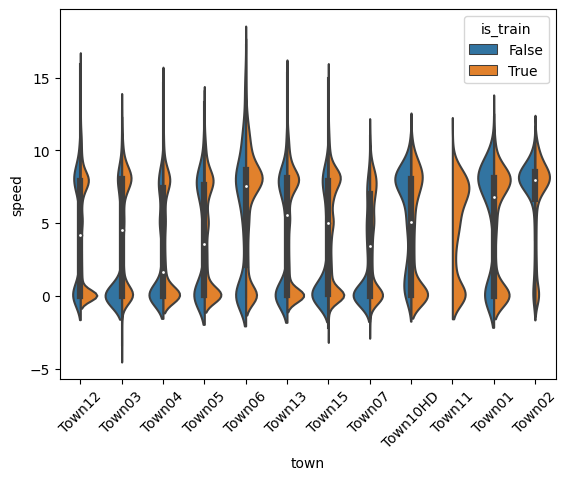

In [15]:
sns.violinplot(data=df, x='town', y='speed', hue='is_train', split=True)
# Rotate x labels 45 degrees
plt.xticks(rotation=45)
plt.show()

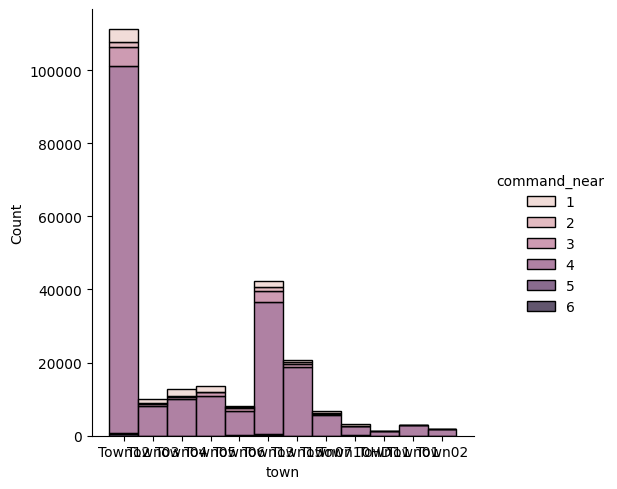

In [23]:
sns.displot(data=df[df['is_train'] == True], x='town', hue='command_near', multiple='stack')

In [6]:
mapped_values = df['expert_action_idx'].map(action_dict)


In [8]:
df[['expert_throttle', 'expert_steer', 'expert_brake', 'is_reversing']] = pd.DataFrame(
    mapped_values.tolist(), index=df.index)

In [11]:
output_path = "bench2drive_base_trainvalfix_expertfix.parquet"
df.to_parquet(output_path, compression='snappy')

csv_path = output_path.replace('.parquet', '.csv')
df.to_csv(csv_path, index=False)

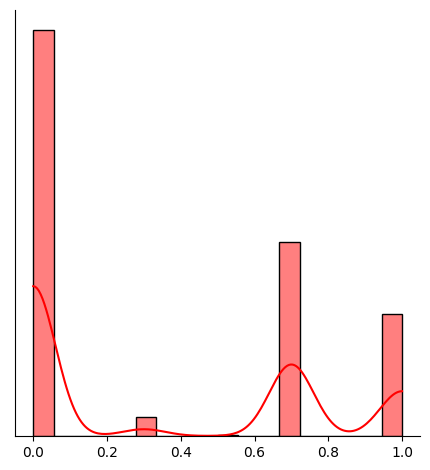

In [ ]:
sns.displot(data=df[df['is_train'] == True][:15000], x='expert_throttle', kde=True, color='red',)

plt.ylabel('')
plt.xlabel('')
plt.yticks([])
plt.show()

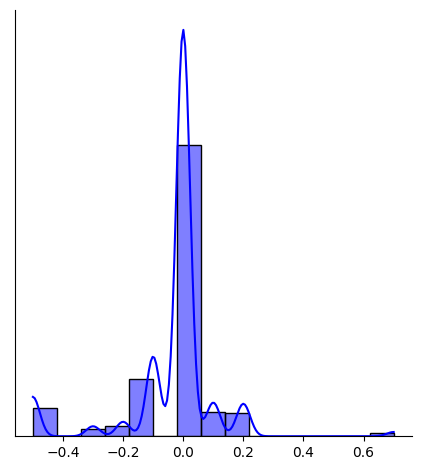

In [85]:
sns.displot(data=df[df['is_train'] == True][:15000], x='expert_steer', kde=True, color='blue')
plt.ylabel('')
plt.xlabel('')
plt.yticks([])
plt.show()

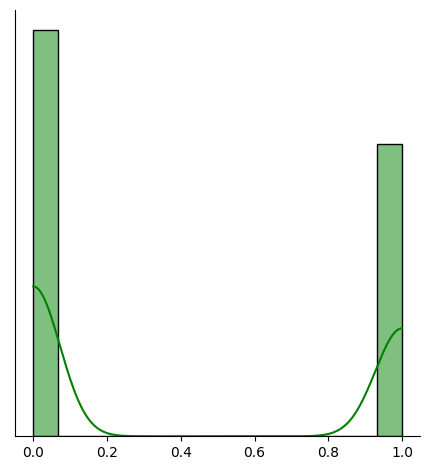

In [86]:
sns.displot(data=df[df['is_train'] == True][:15000], x='expert_brake', kde=True, color='green')
plt.ylabel('')
plt.xlabel('')
plt.yticks([])
plt.show()

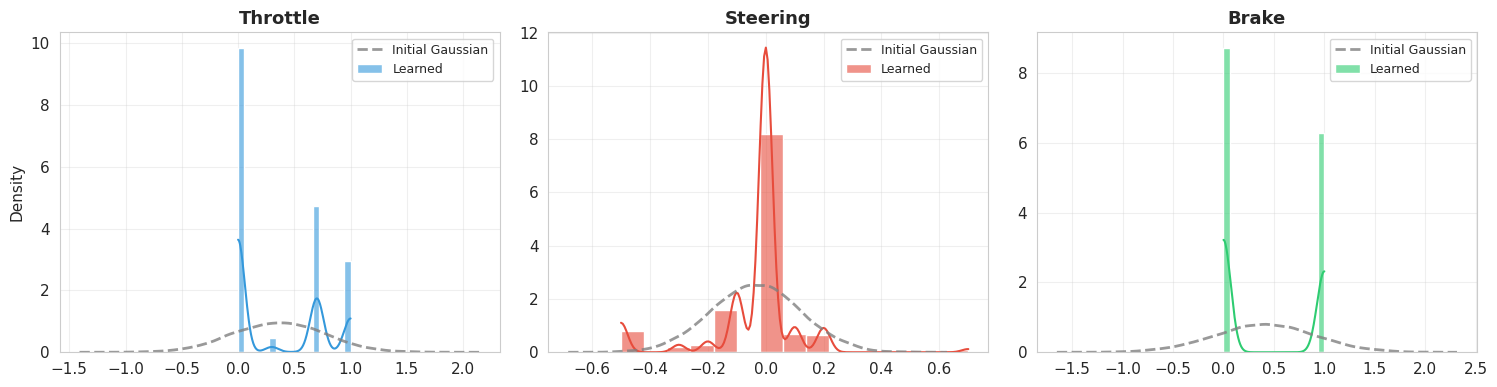

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Colors for each action
colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green
actions = ['expert_throttle', 'expert_steer', 'expert_brake']
titles = ['Throttle', 'Steering', 'Brake']

# Filter training data
train_data = df[df['is_train'] == True][:15000]

for idx, (ax, action, color, title) in enumerate(zip(axes, actions, colors, titles)):
    # Plot Gaussian noise (before diffusion)
    x_range = np.linspace(train_data[action].min(), train_data[action].max(), 100)
    gaussian = np.random.normal(train_data[action].mean(), train_data[action].std(), 10000)
    
    # Plot learned distribution
    sns.histplot(data=train_data, x=action, kde=True, color=color, 
                 ax=ax, stat='density', alpha=0.6, label='Learned')
    
    # Plot initial Gaussian
    sns.kdeplot(gaussian, ax=ax, color='gray', linestyle='--', 
                linewidth=2, label='Initial Gaussian', alpha=0.8)
    
    ax.set_title(f'{title}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Density' if idx == 0 else '')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('diffusion_actions.png', dpi=300, bbox_inches='tight')
plt.show()

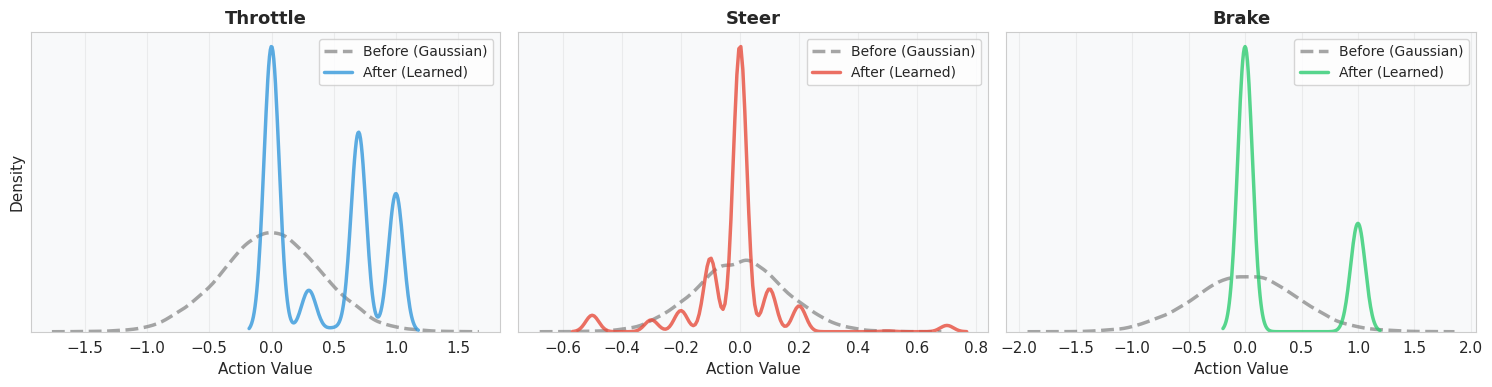

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

actions = [
    ('expert_throttle', 'Throttle', '#3498db'),
    ('expert_steer', 'Steer', '#e74c3c'),
    ('expert_brake', 'Brake', '#2ecc71')
]

train_data = df[df['is_train'] == True].sample(frac=1)[:15000]

for idx, (ax, (action, title, color)) in enumerate(zip(axes, actions)):
    # Initial Gaussian
    gaussian = np.random.normal(0, train_data[action].std(), 15000)
    
    # Plot both distributions as KDE only
    sns.kdeplot(gaussian, ax=ax, color='gray', linestyle='--',
                linewidth=2.5, label='Before (Gaussian)', alpha=0.7)
    sns.kdeplot(data=train_data, x=action, ax=ax, color=color,
                linewidth=2.5, label='After (Learned)', alpha=0.8)
    
    ax.set_title(f'{title}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Action Value', fontsize=11)
    ax.set_ylabel('Density' if idx == 0 else '')
    # Remove y ticks
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('diffusion_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

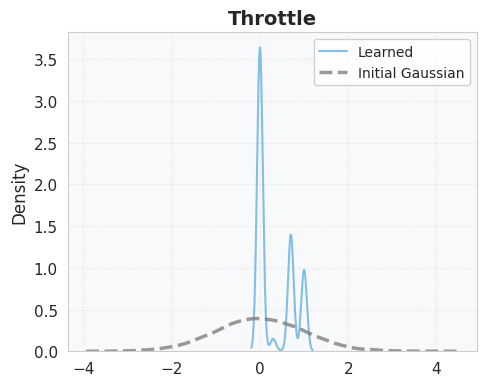

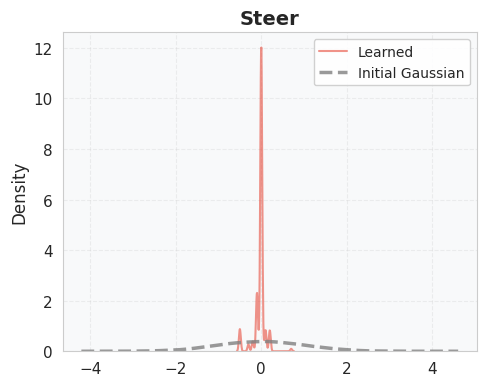

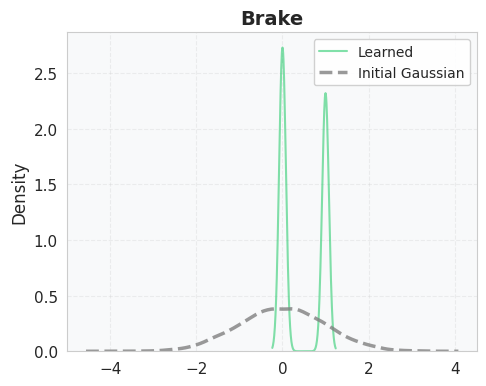

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
actions = [
    ('expert_throttle', 'Throttle', '#3498db'),
    ('expert_steer', 'Steer', '#e74c3c'),
    ('expert_brake', 'Brake', '#2ecc71')
]

train_data = df[df['is_train'] == True][:10000]

for action, title, color in actions:
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Generate initial Gaussian noise
    gaussian = np.random.normal(0, 1, 10000)
    
    # Plot learned distribution (after diffusion)
    sns.kdeplot(data=train_data, x=action, color=color,
                  alpha=0.6, label='Learned', ax=ax)
    
    # Plot initial Gaussian (before diffusion)
    sns.kdeplot(gaussian, ax=ax, color='gray', linestyle='--',
                linewidth=2.5, label='Initial Gaussian', alpha=0.8)
    
    ax.set_title(f'{title}', fontweight='bold', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    plt.savefig(f'diffusion_{action}.png', dpi=300, bbox_inches='tight')
    plt.show()

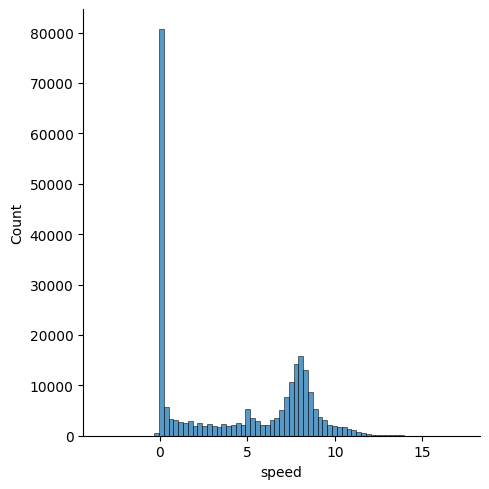

In [15]:
sns.displot(data=df, x='speed', bins=75)
plt.show()

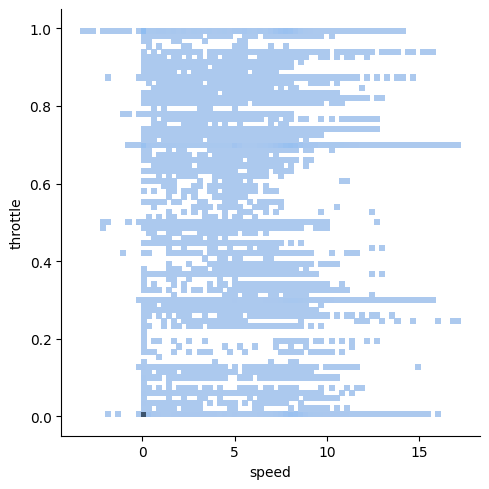

In [24]:
sns.displot(data=df, x='speed', y='throttle', bins=75)
plt.show()

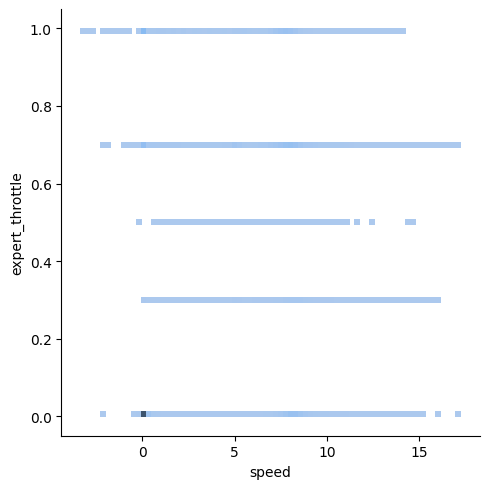

In [23]:
sns.displot(data=df, x='speed', y='expert_throttle', bins=75)
plt.show()

In [38]:
df['speed'].max()

17.265952633313525

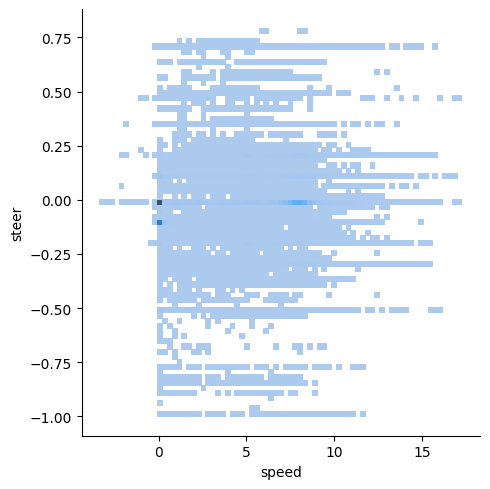

In [34]:
sns.displot(data=df, x='speed', y='steer', bins=75)
plt.show()

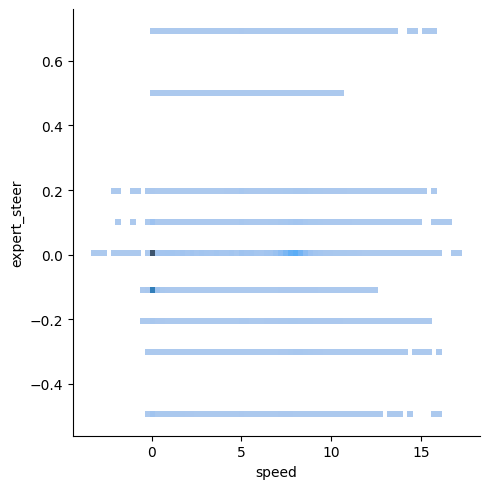

In [35]:
sns.displot(data=df, x='speed', y='expert_steer', bins=75)
plt.show()

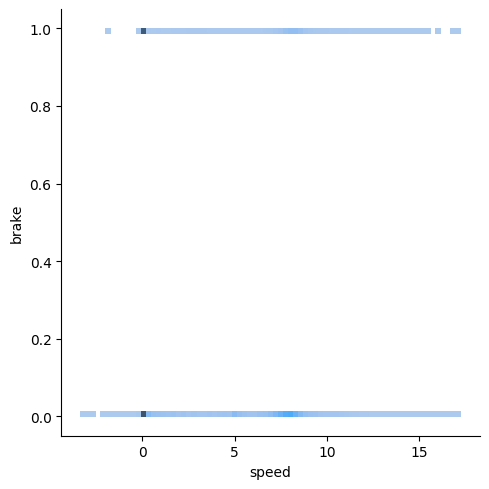

In [32]:
sns.displot(data=df, x='speed', y='brake', bins=75)
plt.show()

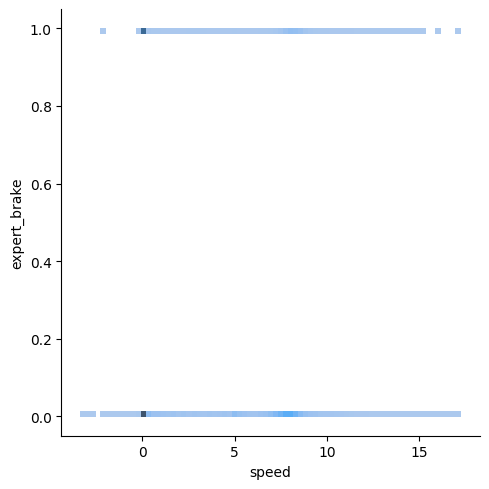

In [33]:
sns.displot(data=df, x='speed', y='expert_brake', bins=75)
plt.show()

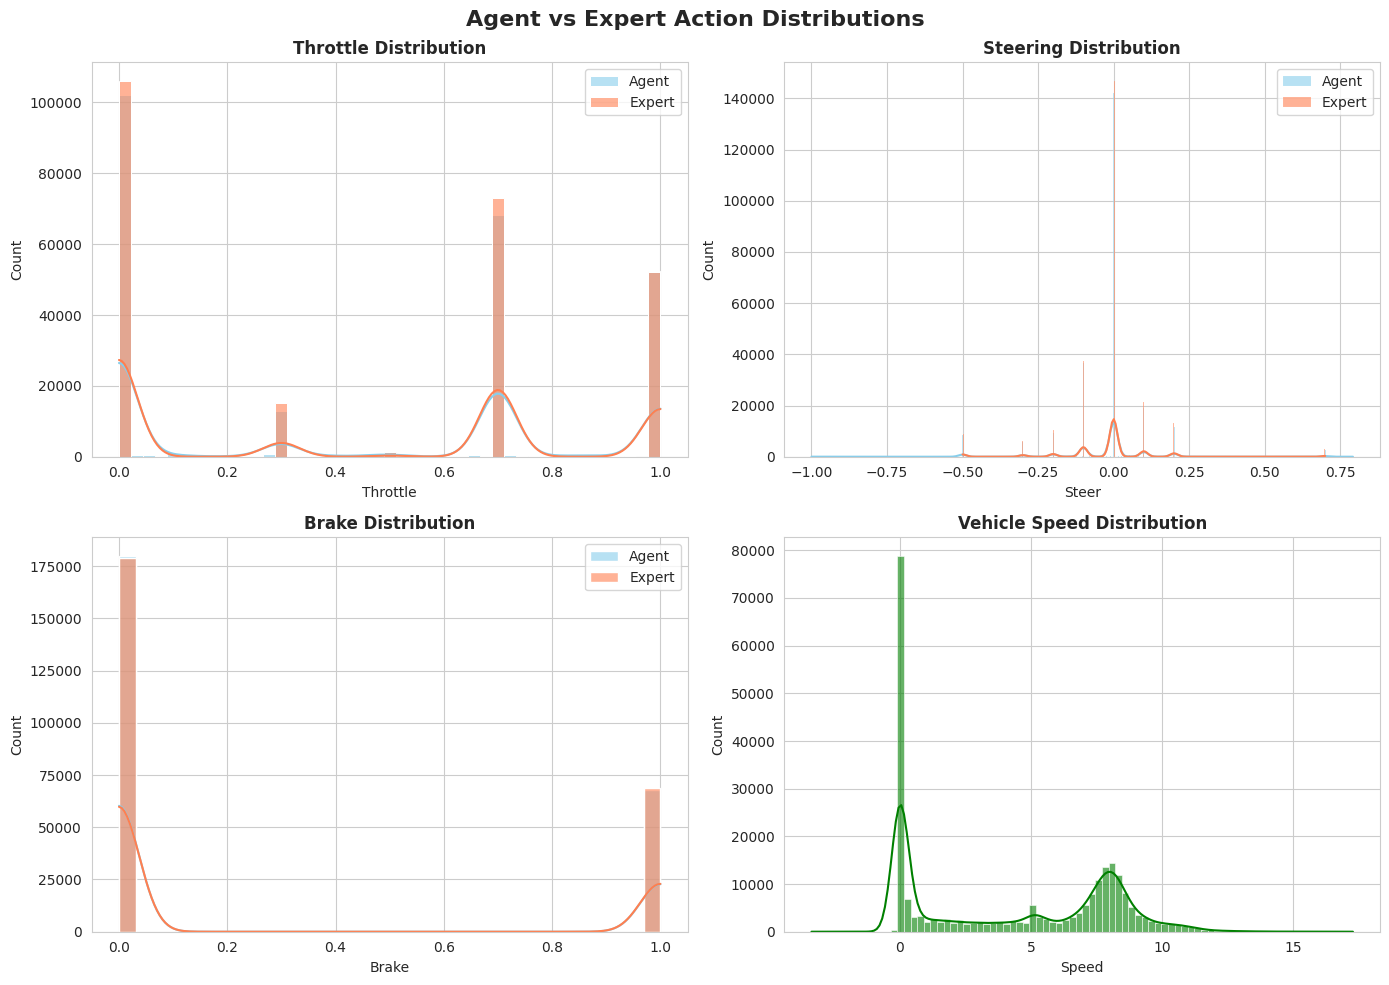

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Agent vs Expert Action Distributions', fontsize=16, fontweight='bold')

# Throttle comparison
sns.histplot(data=df, x='throttle', kde=True, label='Agent', color='skyblue', alpha=0.6, ax=axes[0, 0])
sns.histplot(data=df, x='expert_throttle', kde=True, label='Expert', color='coral', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Throttle Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Throttle')
axes[0, 0].legend()

# Steer comparison
sns.histplot(data=df, x='steer', kde=True, label='Agent', color='skyblue', alpha=0.6, ax=axes[0, 1])
sns.histplot(data=df, x='expert_steer', kde=True, label='Expert', color='coral', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Steering Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Steer')
axes[0, 1].legend()

# Brake comparison
sns.histplot(data=df, x='brake', kde=True, label='Agent', color='skyblue', alpha=0.6, ax=axes[1, 0])
sns.histplot(data=df, x='expert_brake', kde=True, label='Expert', color='coral', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Brake Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Brake')
axes[1, 0].legend()

# Speed distribution
sns.histplot(data=df, x='speed', kde=True, color='green', alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Vehicle Speed Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Speed')

plt.tight_layout()
plt.show()

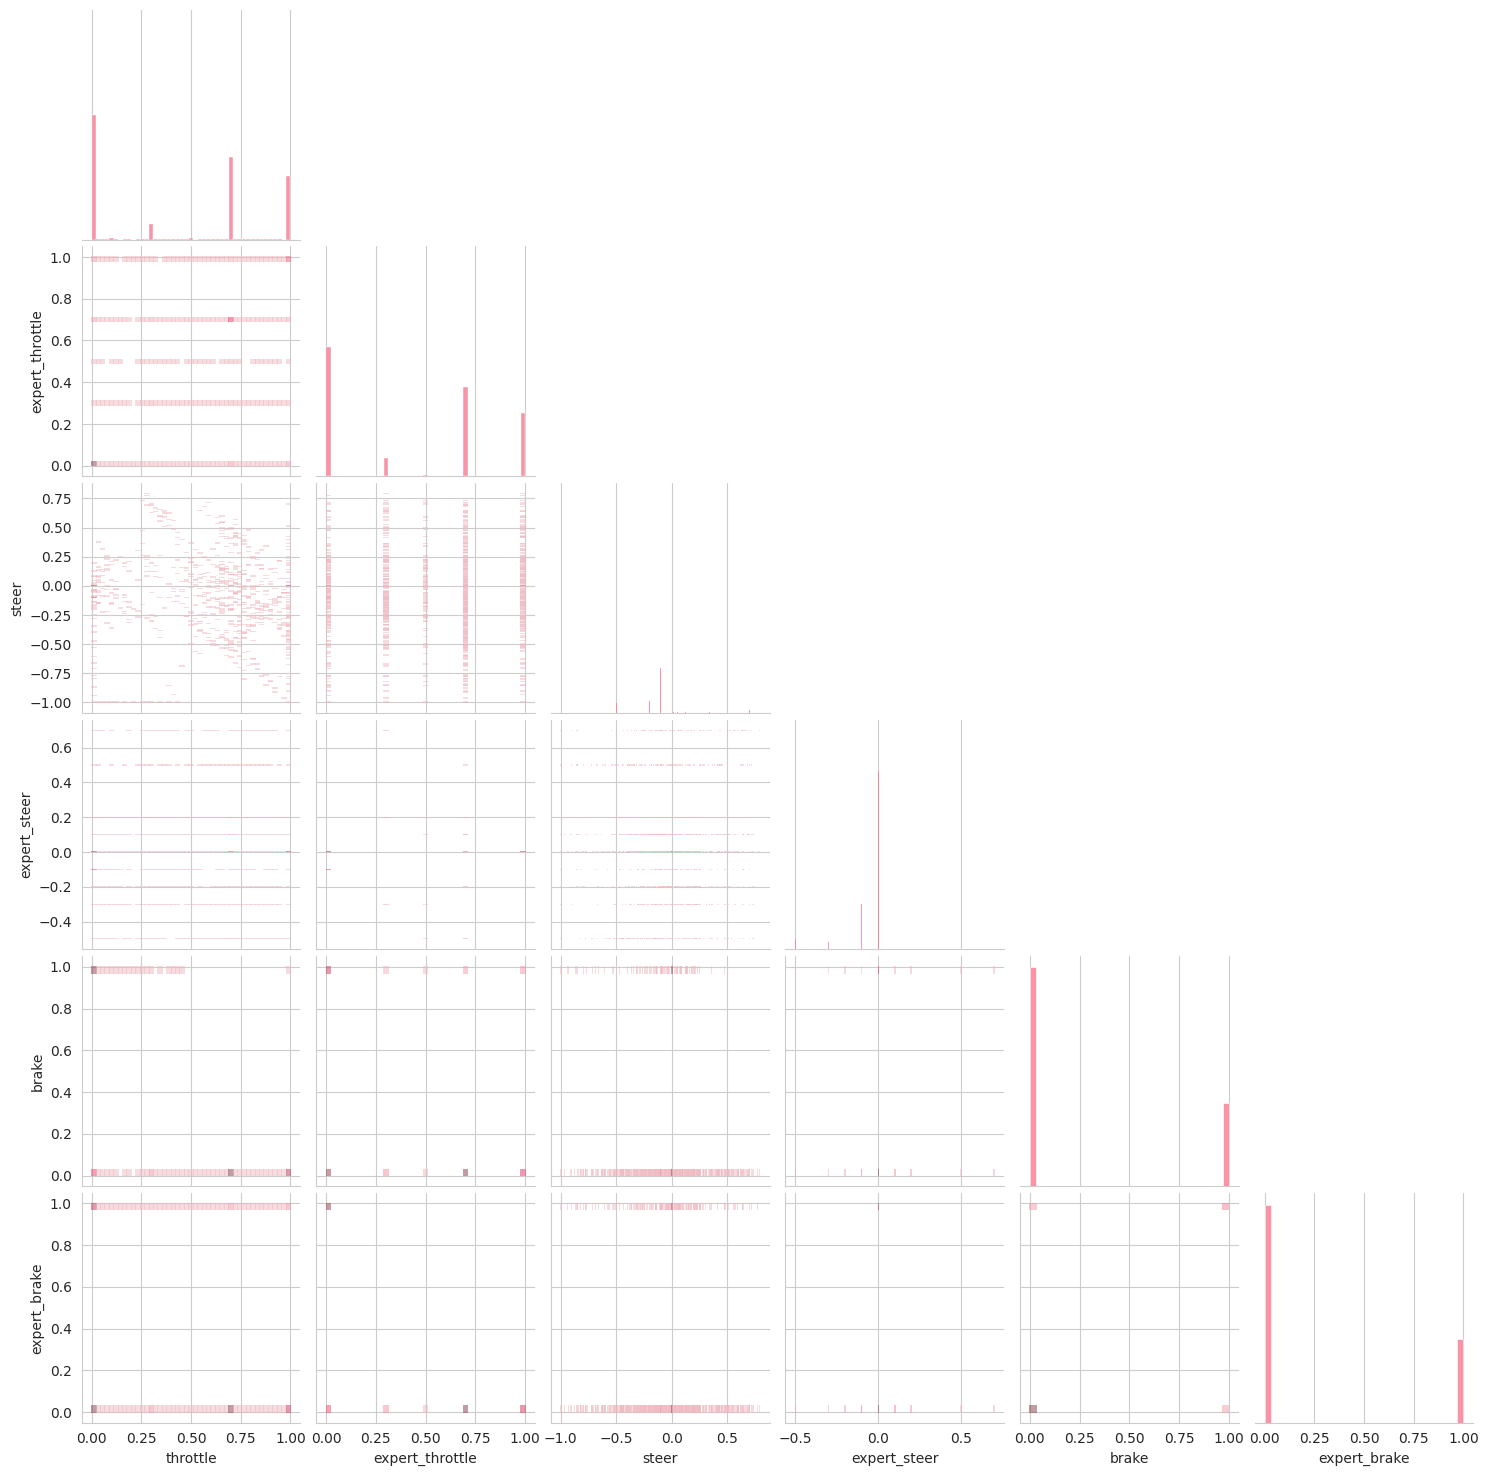

In [45]:
sns.pairplot(data=df[['throttle', 'expert_throttle', 'steer', 'expert_steer', 'brake', 'expert_brake']],
             kind='hist', corner=True, plot_kws={'alpha':0.5})

In [46]:
import numpy as np
from scipy import stats
from scipy.spatial.distance import jensenshannon

def calculate_distribution_distance(df, col1, col2, method='kl', bins=50):
    """
    Calculate distance between two distributions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the columns
    col1 : str
        First column name
    col2 : str
        Second column name
    method : str
        Distance metric: 'kl' (KL divergence), 'js' (Jensen-Shannon), 
        'wasserstein' (Earth Mover's Distance), 'ks' (Kolmogorov-Smirnov)
    bins : int
        Number of bins for histogram-based methods (for 'kl' and 'js')
    
    Returns:
    --------
    float : distance value
    """
    data1 = df[col1].dropna().values
    data2 = df[col2].dropna().values
    
    if method == 'kl':
        # KL Divergence (requires binning)
        # Get common range for both distributions
        min_val = min(data1.min(), data2.min())
        max_val = max(data1.max(), data2.max())
        bin_edges = np.linspace(min_val, max_val, bins + 1)
        
        # Create histograms
        hist1, _ = np.histogram(data1, bins=bin_edges, density=True)
        hist2, _ = np.histogram(data2, bins=bin_edges, density=True)
        
        # Normalize to get probabilities
        hist1 = hist1 / hist1.sum()
        hist2 = hist2 / hist2.sum()
        
        # Add small epsilon to avoid log(0)
        epsilon = 1e-10
        hist1 = hist1 + epsilon
        hist2 = hist2 + epsilon
        
        # Calculate KL divergence
        kl_div = np.sum(hist1 * np.log(hist1 / hist2))
        return kl_div
    
    elif method == 'js':
        # Jensen-Shannon Divergence (symmetric version of KL)
        min_val = min(data1.min(), data2.min())
        max_val = max(data1.max(), data2.max())
        bin_edges = np.linspace(min_val, max_val, bins + 1)
        
        hist1, _ = np.histogram(data1, bins=bin_edges, density=True)
        hist2, _ = np.histogram(data2, bins=bin_edges, density=True)
        
        hist1 = hist1 / hist1.sum()
        hist2 = hist2 / hist2.sum()
        
        # JS divergence (returns distance, which is sqrt of divergence)
        js_distance = jensenshannon(hist1, hist2)
        return js_distance
    
    elif method == 'wasserstein':
        # Wasserstein distance (Earth Mover's Distance)
        # No binning needed, works on raw data
        wasserstein_dist = stats.wasserstein_distance(data1, data2)
        return wasserstein_dist
    
    elif method == 'ks':
        # Kolmogorov-Smirnov statistic
        ks_stat, p_value = stats.ks_2samp(data1, data2)
        return ks_stat
    
    else:
        raise ValueError(f"Unknown method: {method}. Choose from 'kl', 'js', 'wasserstein', 'ks'")


# Example usage:
print("Throttle comparison:")
print(f"  KL Divergence: {calculate_distribution_distance(df, 'throttle', 'expert_throttle', method='kl'):.4f}")
print(f"  JS Distance: {calculate_distribution_distance(df, 'throttle', 'expert_throttle', method='js'):.4f}")
print(f"  Wasserstein: {calculate_distribution_distance(df, 'throttle', 'expert_throttle', method='wasserstein'):.4f}")
print(f"  KS Statistic: {calculate_distribution_distance(df, 'throttle', 'expert_throttle', method='ks'):.4f}")

print("\nSteer comparison:")
print(f"  KL Divergence: {calculate_distribution_distance(df, 'steer', 'expert_steer', method='kl'):.4f}")
print(f"  JS Distance: {calculate_distribution_distance(df, 'steer', 'expert_steer', method='js'):.4f}")
print(f"  Wasserstein: {calculate_distribution_distance(df, 'steer', 'expert_steer', method='wasserstein'):.4f}")
print(f"  KS Statistic: {calculate_distribution_distance(df, 'steer', 'expert_steer', method='ks'):.4f}")


print("\nBrake comparison:")
print(f"  KL Divergence: {calculate_distribution_distance(df, 'brake', 'expert_brake', method='kl'):.4f}")
print(f"  JS Distance: {calculate_distribution_distance(df, 'brake', 'expert_brake', method='js'):.4f}")
print(f"  Wasserstein: {calculate_distribution_distance(df, 'brake', 'expert_brake', method='wasserstein'):.4f}")
print(f"  KS Statistic: {calculate_distribution_distance(df, 'brake', 'expert_brake', method='ks'):.4f}")


Throttle comparison:
  KL Divergence: 0.6761
  JS Distance: 0.1246
  Wasserstein: 0.0056
  KS Statistic: 0.2812

Steer comparison:
  KL Divergence: 0.6186
  JS Distance: 0.1178
  Wasserstein: 0.0048
  KS Statistic: 0.1588

Brake comparison:
  KL Divergence: 0.0000
  JS Distance: 0.0025
  Wasserstein: 0.0031
  KS Statistic: 0.0031


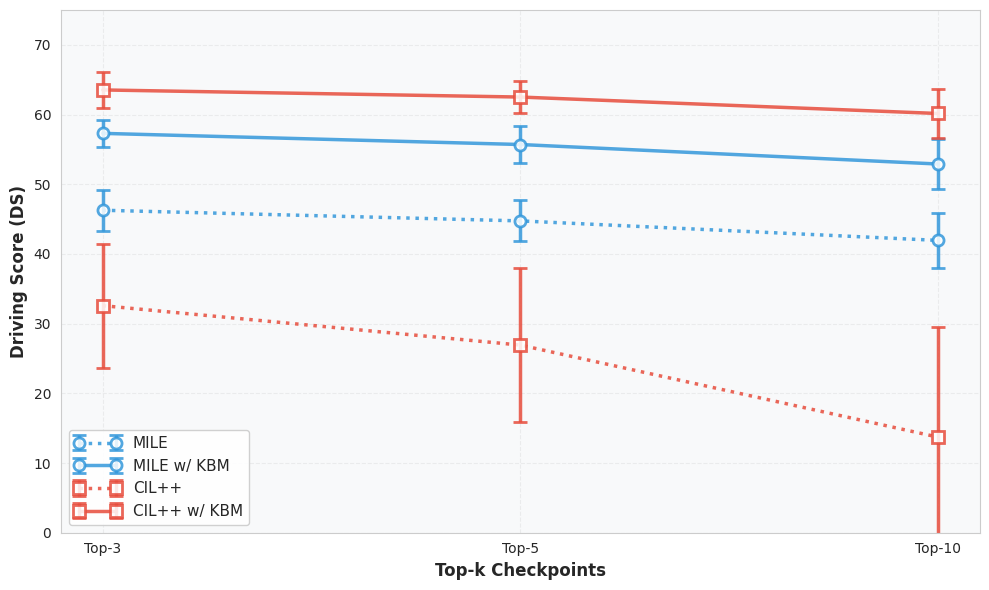

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['MILE', 'MILE w/ KBM', 'CIL++', 'CIL++ w/ KBM']
k_values = ['Top-3', 'Top-5', 'Top-10']

# Mean values
data = {
    'MILE': [46.27, 44.74, 41.94],
    'MILE w/ KBM': [57.30, 55.70, 52.90],
    'CIL++': [32.58, 26.92, 13.71],
    'CIL++ w/ KBM': [63.53, 62.51, 60.15]
}

# Standard deviations
std = {
    'MILE': [2.93, 2.95, 4.00],
    'MILE w/ KBM': [1.97, 2.66, 3.61],
    'CIL++': [8.90, 11.04, 15.75],
    'CIL++ w/ KBM': [2.63, 2.33, 3.54]
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Colors for model families (same color for base and KBM versions)
colors = {
    'MILE': '#3498db',
    'MILE w/ KBM': '#3498db',
    'CIL++': '#e74c3c',
    'CIL++ w/ KBM': '#e74c3c'
}

# Line styles (dashed for base, solid for KBM)
linestyles = {
    'MILE': ':',
    'MILE w/ KBM': '-',
    'CIL++': ':',
    'CIL++ w/ KBM': '-'
}

# Markers
markers = {
    'MILE': 'o',
    'MILE w/ KBM': 'o',
    'CIL++': 's',
    'CIL++ w/ KBM': 's'
}

# Plot each model
x = np.arange(len(k_values))
for model in models:
    ax.errorbar(x, data[model], yerr=std[model], 
                label=model, marker=markers[model], markersize=8,
                linewidth=2.5, capsize=5, capthick=2,
                color=colors[model], linestyle=linestyles[model],
                alpha=0.85, markerfacecolor='white', markeredgewidth=2)

# Customize plot
ax.set_xlabel('Top-k Checkpoints', fontsize=12, fontweight='bold')
ax.set_ylabel('Driving Score (DS)', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(k_values)
ax.legend(loc='best', fontsize=11, framealpha=0.9, numpoints=2, handlelength=3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 75)

# Add a subtle background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()